# Descomposición canónica. 

Consideremos la cadena de Markov en tiempo discreto con espacio de estados $E=\{a,b,c,d,e,f,g\}$, en el orden $(a,b,c,d,e,f,g)$, y matriz de transición $P$.

In [5]:
import numpy as np
import pandas as pd
import sympy as sp
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.figsize"] = (9, 5)

## 1. Matriz $P$ y diagrama de transiciones



In [2]:
estados = ["a", "b", "c", "d", "e", "f", "g"]

P = sp.Matrix([
    [sp.Rational(1, 4), 0, 0, 0, 0, 0, sp.Rational(3, 4)],
    [sp.Rational(1, 8), sp.Rational(1, 8), sp.Rational(1, 4), 0, sp.Rational(1, 4), sp.Rational(1, 8), sp.Rational(1, 8)],
    [0, 0, sp.Rational(2, 5), sp.Rational(1, 5), sp.Rational(2, 5), 0, 0],
    [0, 0, sp.Rational(1, 2), sp.Rational(1, 2), 0, 0, 0],
    [0, 0, 0, sp.Rational(1, 2), sp.Rational(1, 2), 0, 0],
    [0, sp.Rational(1, 5), 0, sp.Rational(1, 5), sp.Rational(1, 5), sp.Rational(1, 5), sp.Rational(1, 5)],
    [sp.Rational(4, 5), 0, 0, 0, 0, 0, sp.Rational(1, 5)]
])

P_num = np.array(P.tolist(), dtype=float)

def tabla_fracciones(M, filas, columnas):
    """Devuelve una tabla con las entradas de una matriz escrita como fracciones."""
    return pd.DataFrame(
        [[str(M[i, j]) for j in range(M.shape[1])] for i in range(M.shape[0])],
        index=filas,
        columns=columnas
    )

display(tabla_fracciones(P, estados, estados))

,a,b,c,d,e,f,g
a,1/4,0,0,0,0,0,3/4
b,1/8,1/8,1/4,0,1/4,1/8,1/8
c,0,0,2/5,1/5,2/5,0,0
d,0,0,1/2,1/2,0,0,0
e,0,0,0,1/2,1/2,0,0
f,0,1/5,0,1/5,1/5,1/5,1/5
g,4/5,0,0,0,0,0,1/5


Se verifica que $P$ sea una matriz de transición: todas sus entradas deben ser no negativas y cada fila debe sumar $1$.

In [3]:
entradas_no_negativas = all(P[i, j] >= 0 for i in range(P.rows) for j in range(P.cols))
sumas_filas = [sum(P[i, j] for j in range(P.cols)) for i in range(P.rows)]
filas_suman_uno = all(s == 1 for s in sumas_filas)

verificacion = pd.DataFrame({
    "suma de la fila": [str(s) for s in sumas_filas]
}, index=estados)

display(verificacion)
print("Entradas no negativas:", entradas_no_negativas)
print("Filas con suma 1:", filas_suman_uno)

,suma de la fila
a,1
b,1
c,1
d,1
e,1
f,1
g,1


Entradas no negativas: True
Filas con suma 1: True


La matriz $P$ es una matriz de transición válida, porque todas sus entradas son no negativas y la suma de cada renglón es igual a $1$.

Las sumas por renglón son:

$1,\;1,\;1,\;1,\;1,\;1,\;1.$

Por lo tanto, $P$ cumple las condiciones necesarias para representar una cadena de Markov en tiempo discreto.

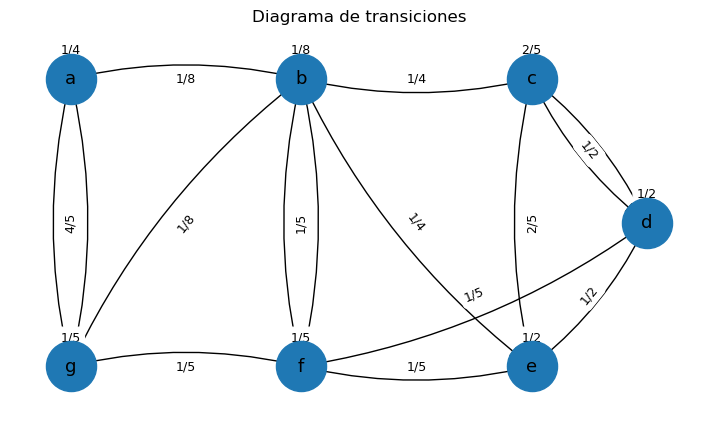

In [6]:
G = nx.DiGraph()
G.add_nodes_from(estados)

for i, origen in enumerate(estados):
    for j, destino in enumerate(estados):
        if P[i, j] > 0:
            G.add_edge(origen, destino, weight=str(P[i, j]))

pos = {
    "a": (-2, 1), "g": (-2, -1),
    "b": (0, 1),  "f": (0, -1),
    "c": (2, 1),  "d": (3, 0), "e": (2, -1)
}

plt.figure()
nx.draw_networkx_nodes(G, pos, node_size=1300)
nx.draw_networkx_labels(G, pos, font_size=13)
nx.draw_networkx_edges(
    G, pos,
    arrows=True,
    arrowsize=18,
    connectionstyle="arc3,rad=0.12"
)

etiquetas = {(u, v): datos["weight"] for u, v, datos in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=etiquetas, font_size=9)

plt.title("Diagrama de transiciones")
plt.axis("off")
plt.show()

## 2. Distribución límite

Para decidir si hay una distribución límite global se identifican las clases comunicantes y las clases cerradas.

In [7]:
def clases_comunicantes(P, estados, tol=1e-12):
    """Calcula las clases comunicantes mediante componentes fuertemente conexas."""
    G = nx.DiGraph()
    G.add_nodes_from(estados)
    
    for i, origen in enumerate(estados):
        for j, destino in enumerate(estados):
            if float(P[i, j]) > tol:
                G.add_edge(origen, destino)
    
    clases = [sorted(list(c), key=estados.index) for c in nx.strongly_connected_components(G)]
    clases = sorted(clases, key=lambda c: min(estados.index(x) for x in c))
    return clases


def es_cerrada(P, estados, clase, tol=1e-12):
    """Una clase es cerrada si no tiene transiciones positivas hacia fuera."""
    clase = set(clase)
    for origen in clase:
        i = estados.index(origen)
        for j, destino in enumerate(estados):
            if destino not in clase and float(P[i, j]) > tol:
                return False
    return True

clases = clases_comunicantes(P, estados)
resumen_clases = []

for clase in clases:
    cerrada = es_cerrada(P, estados, clase)
    tipo = "cerrada recurrente" if cerrada else "no cerrada transitoria"
    resumen_clases.append(["{" + ", ".join(clase) + "}", tipo])

resumen_clases = pd.DataFrame(resumen_clases, columns=["clase", "tipo"])
display(resumen_clases)

,clase,tipo
0,"{a, g}",cerrada recurrente
1,"{b, f}",no cerrada transitoria
2,"{c, d, e}",cerrada recurrente


A partir del diagrama de transiciones, las clases comunicantes son:

$\{a,g\},\qquad \{b,f\},\qquad \{c,d,e\}.$

La clase $\{a,g\}$ es cerrada, porque desde $a$ y $g$ solo se puede transitar hacia estados dentro de la misma clase.

La clase $\{c,d,e\}$ también es cerrada, porque desde $c,d,e$ no existe transición hacia estados fuera de esa clase.

La clase $\{b,f\}$ no es cerrada, ya que desde $b$ y $f$ existen transiciones hacia estados de las clases cerradas.

Entonces, no existe una distribución límite global única para toda la cadena, ya que el comportamiento final depende de la clase cerrada alcanzada. Pero, si existe el límite de $P^n$, porque las clases cerradas tienen periodo $1$ al poseer lazos propios.

## 3. Descomposición canónica y límite de $P^n$

Se coloca primero la clase transitoria y después las clases cerradas. El orden canónico utilizado es $(b,f,a,g,c,d,e)$.

In [18]:
orden_canonico = ["b", "f", "a", "g", "c", "d", "e"]
indices_canonicos = [estados.index(s) for s in orden_canonico]

P_can = P.extract(indices_canonicos, indices_canonicos)

display(tabla_fracciones(P_can, orden_canonico, orden_canonico))

,b,f,a,g,c,d,e
b,1/8,1/8,1/8,1/8,1/4,0,1/4
f,1/5,1/5,0,1/5,0,1/5,1/5
a,0,0,1/4,3/4,0,0,0
g,0,0,4/5,1/5,0,0,0
c,0,0,0,0,2/5,1/5,2/5
d,0,0,0,0,1/2,1/2,0
e,0,0,0,0,0,1/2,1/2


Con este orden, la matriz queda organizada por bloques: $Q$ para los estados transitorios, $R_1$ hacia $\{a,g\}$, $R_2$ hacia $\{c,d,e\}$, y las submatrices cerradas $P_{ag}$ y $P_{cde}$.

In [19]:

Q = P_can[:2, :2]
R1 = P_can[:2, 2:4]
R2 = P_can[:2, 4:7]
P_ag = P_can[2:4, 2:4]
P_cde = P_can[4:7, 4:7]

print("Q")
display(tabla_fracciones(Q, ["b", "f"], ["b", "f"]))

print("R1")
display(tabla_fracciones(R1, ["b", "f"], ["a", "g"]))

print("R2")
display(tabla_fracciones(R2, ["b", "f"], ["c", "d", "e"]))

print("P_ag")
display(tabla_fracciones(P_ag, ["a", "g"], ["a", "g"]))

print("P_cde")
display(tabla_fracciones(P_cde, ["c", "d", "e"], ["c", "d", "e"]))

Q


,b,f
b,1/8,1/8
f,1/5,1/5


R1


,a,g
b,1/8,1/8
f,0,1/5


R2


,c,d,e
b,1/4,0,1/4
f,0,1/5,1/5


P_ag


,a,g
a,1/4,3/4
g,4/5,1/5


P_cde


,c,d,e
c,2/5,1/5,2/5
d,1/2,1/2,0
e,0,1/2,1/2


Se calculan las distribuciones límite de las submatrices cerradas resolviendo $\pi P=\pi$ y $\sum_i \pi_i=1$.

In [20]:
def distribucion_estacionaria(M):
    """Resuelve pi M = pi con suma de entradas igual a 1."""
    n = M.rows
    variables = sp.symbols(f"p0:{n}")
    ecuaciones = []
    
    for j in range(n):
        ecuaciones.append(sp.Eq(sum(variables[i] * M[i, j] for i in range(n)), variables[j]))
    
    ecuaciones.append(sp.Eq(sum(variables), 1))
    solucion = sp.solve(ecuaciones, variables, dict=True)[0]
    return sp.Matrix([[sp.simplify(solucion[v]) for v in variables]])

pi_ag = distribucion_estacionaria(P_ag)
pi_cde = distribucion_estacionaria(P_cde)

pi_ag_df = tabla_fracciones(pi_ag, ["pi_ag"], ["a", "g"])
pi_cde_df = tabla_fracciones(pi_cde, ["pi_cde"], ["c", "d", "e"])

print("Distribución límite de P_ag")
display(pi_ag_df)

print("Distribución límite de P_cde")
display(pi_cde_df)

Distribución límite de P_ag


,a,g
pi_ag,16/31,15/31


Distribución límite de P_cde


,c,d,e
pi_cde,1/3,2/5,4/15


Las distribuciones límite de las submatrices cerradas son $\pi_{ag}=(16/31,15/31)$ y $\pi_{cde}=(1/3,2/5,4/15)$. Para los estados transitorios se calculan las probabilidades de llegada a cada clase cerrada mediante la matriz fundamental $N=(I-Q)^{-1}$.

In [21]:
N = (sp.eye(Q.rows) - Q).inv()

# Probabilidad total de llegar a cada clase cerrada desde b y f
h_ag = N * R1 * sp.ones(R1.cols, 1)
h_cde = N * R2 * sp.ones(R2.cols, 1)

absorcion = pd.DataFrame({
    "P(llegar a {a,g})": [str(h_ag[i, 0]) for i in range(h_ag.rows)],
    "P(llegar a {c,d,e})": [str(h_cde[i, 0]) for i in range(h_cde.rows)]
}, index=["b", "f"])

print("Matriz fundamental N")
display(tabla_fracciones(N, ["b", "f"], ["b", "f"]))

print("Probabilidades de llegada a las clases cerradas")
display(absorcion)

Matriz fundamental N


,b,f
b,32/27,5/27
f,8/27,35/27


Probabilidades de llegada a las clases cerradas


,"P(llegar a {a,g})","P(llegar a {c,d,e})"
b,1/3,2/3
f,1/3,2/3


Desde $b$ y desde $f$ la probabilidad de llegar a $\{a,g\}$ es $1/3$, mientras que la probabilidad de llegar a $\{c,d,e\}$ es $2/3$. Con estas probabilidades se forma el límite de $P^n$.

In [22]:
L_can = sp.zeros(7, 7)

# Filas de los estados transitorios b y f
for i in range(2):
    L_can[i, 2] = h_ag[i, 0] * pi_ag[0, 0]
    L_can[i, 3] = h_ag[i, 0] * pi_ag[0, 1]
    L_can[i, 4] = h_cde[i, 0] * pi_cde[0, 0]
    L_can[i, 5] = h_cde[i, 0] * pi_cde[0, 1]
    L_can[i, 6] = h_cde[i, 0] * pi_cde[0, 2]

# Filas de la clase cerrada {a,g}
for i in [2, 3]:
    L_can[i, 2] = pi_ag[0, 0]
    L_can[i, 3] = pi_ag[0, 1]

# Filas de la clase cerrada {c,d,e}
for i in [4, 5, 6]:
    L_can[i, 4] = pi_cde[0, 0]
    L_can[i, 5] = pi_cde[0, 1]
    L_can[i, 6] = pi_cde[0, 2]

print("Límite en orden canónico")
display(tabla_fracciones(L_can, orden_canonico, orden_canonico))

Límite en orden canónico


,b,f,a,g,c,d,e
b,0,0,16/93,5/31,2/9,4/15,8/45
f,0,0,16/93,5/31,2/9,4/15,8/45
a,0,0,16/31,15/31,0,0,0
g,0,0,16/31,15/31,0,0,0
c,0,0,0,0,1/3,2/5,4/15
d,0,0,0,0,1/3,2/5,4/15
e,0,0,0,0,1/3,2/5,4/15


El límite anterior está en el orden canónico. Se reordena al orden original $(a,b,c,d,e,f,g)$ para reportar el resultado sobre la matriz inicial.

In [23]:
L_original = sp.zeros(7, 7)

for i_can, estado_i in enumerate(orden_canonico):
    i_original = estados.index(estado_i)
    for j_can, estado_j in enumerate(orden_canonico):
        j_original = estados.index(estado_j)
        L_original[i_original, j_original] = L_can[i_can, j_can]

print("Límite en el orden original")
display(tabla_fracciones(L_original, estados, estados))

Límite en el orden original


,a,b,c,d,e,f,g
a,16/31,0,0,0,0,0,15/31
b,16/93,0,2/9,4/15,8/45,0,5/31
c,0,0,1/3,2/5,4/15,0,0
d,0,0,1/3,2/5,4/15,0,0
e,0,0,1/3,2/5,4/15,0,0
f,16/93,0,2/9,4/15,8/45,0,5/31
g,16/31,0,0,0,0,0,15/31


El límite matricial es:

$\lim_{n\to\infty}P^n=
\begin{pmatrix}
\frac{16}{31}&0&0&0&0&0&\frac{15}{31}\\
\frac{16}{93}&0&\frac29&\frac{4}{15}&\frac{8}{45}&0&\frac{5}{31}\\
0&0&\frac13&\frac25&\frac{4}{15}&0&0\\
0&0&\frac13&\frac25&\frac{4}{15}&0&0\\
0&0&\frac13&\frac25&\frac{4}{15}&0&0\\
\frac{16}{93}&0&\frac29&\frac{4}{15}&\frac{8}{45}&0&\frac{5}{31}\\
\frac{16}{31}&0&0&0&0&0&\frac{15}{31}
\end{pmatrix}.$

Las filas correspondientes a $a$ y $g$ coinciden con la distribución límite de la clase $\{a,g\}$.

Las filas correspondientes a $c,d,e$ coinciden con la distribución límite de la clase $\{c,d,e\}$.

Las filas correspondientes a $b$ y $f$ son combinaciones ponderadas de las dos distribuciones límite. La ponderación está dada por las probabilidades de absorción $\frac13$ y $\frac23$.



In [25]:
# Comparación numérica con una potencia grande de P
P_num = np.array(P.tolist(), dtype=float)
L_num = np.array(L_original.tolist(), dtype=float)

n = 100
P_n = np.linalg.matrix_power(P_num, n)
error_maximo = np.max(np.abs(P_n - L_num))

print(f"Error máximo entre P^{n} y el límite:", error_maximo)

Error máximo entre P^100 y el límite: 3.9968028886505635e-15


El error numérico es cercano a cero; por tanto, la potencia $P^n$ converge a la matriz límite calculada.

## 4. Descomposición canónica


In [34]:
def descomposicion_canonica(P, estados=None, tol=1e-12):
    
    P = np.array(P, dtype=float)
    
    if P.ndim != 2 or P.shape[0] != P.shape[1]:
        raise ValueError("La matriz debe ser cuadrada.")
    
    n = P.shape[0]
    
    if estados is None:
        estados = list(range(n))
    
    if len(estados) != n:
        raise ValueError("La lista de estados no coincide con el tamaño de la matriz.")
    
    if np.any(P < -tol):
        raise ValueError("La matriz tiene entradas negativas.")
    
    if not np.allclose(P.sum(axis=1), np.ones(n), atol=tol):
        raise ValueError("Al menos una fila no suma 1.")
    
    G = nx.DiGraph()
    G.add_nodes_from(estados)
    
    for i, origen in enumerate(estados):
        for j, destino in enumerate(estados):
            if P[i, j] > tol:
                G.add_edge(origen, destino)
    
    clases = [sorted(list(c), key=estados.index) for c in nx.strongly_connected_components(G)]
    clases = sorted(clases, key=lambda c: min(estados.index(x) for x in c))
    
    clases_cerradas = []
    clases_no_cerradas = []
    
    for clase in clases:
        clase_set = set(clase)
        cerrada = True
        
        for origen in clase:
            i = estados.index(origen)
            for j, destino in enumerate(estados):
                if destino not in clase_set and P[i, j] > tol:
                    cerrada = False
        
        if cerrada:
            clases_cerradas.append(clase)
        else:
            clases_no_cerradas.append(clase)
    
    estados_transitorios = [x for clase in clases_no_cerradas for x in clase]
    estados_recurrentes = [x for clase in clases_cerradas for x in clase]
    orden_canonico = estados_transitorios + estados_recurrentes
    indices = [estados.index(x) for x in orden_canonico]
    P_canonica = P[np.ix_(indices, indices)]
    
    return {
        "clases_comunicantes": clases,
        "clases_cerradas": clases_cerradas,
        "clases_no_cerradas": clases_no_cerradas,
        "estados_transitorios": estados_transitorios,
        "estados_recurrentes": estados_recurrentes,
        "orden_canonico": orden_canonico,
        "P_canonica": P_canonica
    }

In [33]:
resultado = descomposicion_canonica(P_num, estados)

resumen = pd.DataFrame({
    "resultado": [
        resultado["clases_comunicantes"],
        resultado["clases_cerradas"],
        resultado["clases_no_cerradas"],
        resultado["estados_transitorios"],
        resultado["estados_recurrentes"],
        resultado["orden_canonico"]
    ]
}, index=[
    "clases comunicantes",
    "clases cerradas",
    "clases no cerradas",
    "estados transitorios",
    "estados recurrentes",
    "orden canónico"
])

display(resumen)

display(pd.DataFrame(
    resultado["P_canonica"],
    index=resultado["orden_canonico"],
    columns=resultado["orden_canonico"]
))

,resultado
clases comunicantes,"[[a, g], [b, f], [c, d, e]]"
clases cerradas,"[[a, g], [c, d, e]]"
clases no cerradas,"[[b, f]]"
estados transitorios,"[b, f]"
estados recurrentes,"[a, g, c, d, e]"
orden canónico,"[b, f, a, g, c, d, e]"


,b,f,a,g,c,d,e
b,0.125,0.125,0.125,0.125,0.25,0.0,0.25
f,0.200,0.200,0.000,0.200,0.00,0.2,0.20
a,0.000,0.000,0.250,0.750,0.00,0.0,0.00
g,0.000,0.000,0.800,0.200,0.00,0.0,0.00
c,0.000,0.000,0.000,0.000,0.40,0.2,0.40
d,0.000,0.000,0.000,0.000,0.50,0.5,0.00
e,0.000,0.000,0.000,0.000,0.00,0.5,0.50



Si la cadena inicia en $a$ o $g$, permanece en la clase cerrada $\{a,g\}$ y converge a la distribución $\pi_{ag}$.

Si la cadena inicia en $c,d$ o $e$, permanece en la clase cerrada $\{c,d,e\}$ y converge a la distribución $\pi_{cde}$.

Si la cadena inicia en $b$ o $f$, eventualmente entra en una de las dos clases cerradas. Entra a $\{a,g\}$ con probabilidad $\frac13$ y a $\{c,d,e\}$ con probabilidad $\frac23$.

Por esta razón, el comportamiento límite depende del estado inicial y no existe una única distribución límite común para todos los estados.